In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator

from collections import defaultdict

from scipy.ndimage import median_filter
from scipy.signal import savgol_filter

%load_ext line_profiler

import plotparams 
plotparams.default

source = '/cosma5/data/durham/dc-pick2/simulations'

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [9]:
%run ./utils.ipynb

In [13]:
glob_dfs_by_experiment = {}

In [20]:
experiment_path = source + '/Concentration'
glob_dfs_by_experiment['Concentration'] = get_glob_dfs(experiment_path)

/tmp/ipykernel_3592300/1090751299.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)


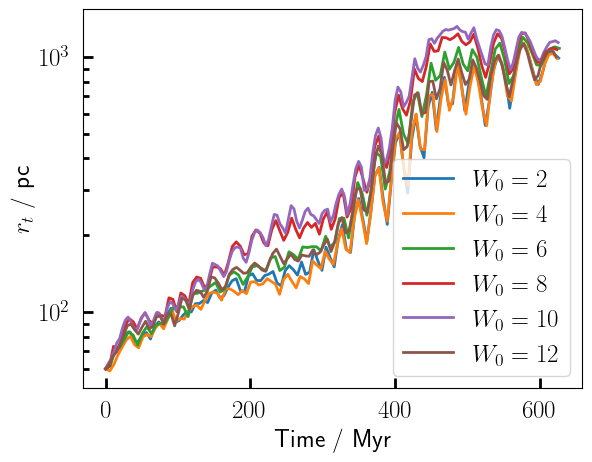

In [24]:
fig, ax = plt.subplots()

for run, glob in glob_dfs_by_experiment['Concentration'].items():
    ax.plot(glob['TIME[Myr]'], glob['RTIDE[PC]'], label=fr'$W_0={{{run}}}$', linewidth=2)

ax.set_yscale('log')
ax.set_xlabel('Time / Myr')
ax.set_ylabel(r'$r_t$ / pc')

ax.legend()
plt.show()

In [72]:
experiment_path = source + '/Mass'
glob_dfs_by_experiment['Mass'] = get_glob_dfs(experiment_path)

/tmp/ipykernel_3592300/1090751299.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)


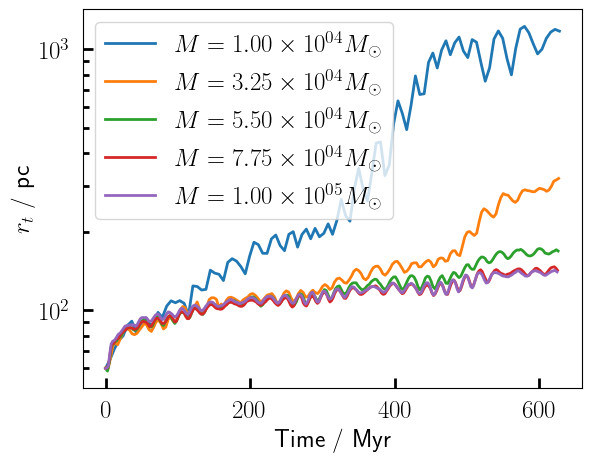

In [73]:
fig, ax = plt.subplots()

for run, glob in glob_dfs_by_experiment['Mass'].items():
    mantissa, exponent = f"{run:.2e}".split("e+")
    ax.plot(glob['TIME[Myr]'], glob['RTIDE[PC]'], 
            label=fr'$M={{{mantissa}}}\times 10^{{{exponent}}} M_\odot$', linewidth=2)
    
ax.set_yscale('log')

ax.set_xlabel('Time / Myr')
ax.set_ylabel(r'$r_t$ / pc')

ax.legend()
plt.show()

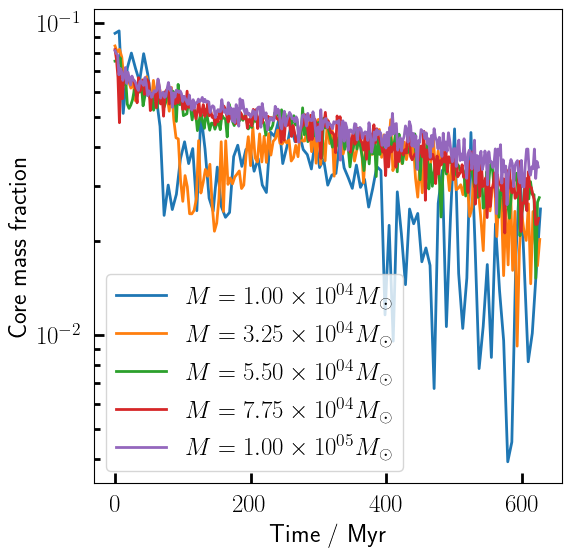

In [89]:
fig, ax = plt.subplots(figsize=(6,6))
for run, df in glob_dfs_by_experiment['Mass'].items():
    mantissa, exponent = f"{run:.2e}".split("e+")
    ax.plot(df['TIME[Myr]'], df['MC[M*]']/run, 
            label=fr'$M={{{mantissa}}}\times 10^{{{exponent}}} M_\odot$', linewidth=2)

ax.set_yscale('log')

ax.set_xlabel('Time / Myr')
ax.set_ylabel('Core mass fraction')
ax.legend()

In [79]:
glob_dfs_by_experiment['Mass'][10000].keys()#['RDENS']

Index(['TIME[NB}', 'TIME[Myr]', 'TCR[Myr]', 'DE', 'BE(3)', 'RSCALE[PC]',
       'RTIDE[PC]', 'RDENS[PC]', 'RC[PC]', 'RHOD[M*]', 'RHOM[M*]', 'MC[M*]',
       'CMAX', '<Cn>', 'Ir/R', 'RCM', 'VCM', 'AZ', 'EB/E', 'EM/E', 'VRMS', 'N',
       'NS', 'NPAIRS', 'NUPKS', 'NPKS', 'NMERGE', 'MULT', '<NB>', 'NC', 'NESC',
       'NSTEPI', 'NSTEPB', 'NSTEPR', 'NSTEPU', 'NSTEPT', 'NSTEPQ', 'NSTEPC',
       'NBLOCK', 'NBLCKR', 'NNPRED', 'NIRRF', 'NBCORR', 'NBFLUX', 'NBFULL',
       'NBVOID', 'NICONV', 'NLSMIN', 'NBSMIN', 'NBDIS', 'NBDIS2', 'NCMDER',
       'NFAST', 'NBFAST', 'NKSTRY', 'NKSREG', 'NKSHYP', 'NKSPER',
       'NKSMODNTTRY', 'NTRIP', 'NQUAD', 'NCHAIN', 'NMERG', 'NEWHI'],
      dtype='str')

In [81]:
glob_dfs_by_experiment['Mass'][10000]['NEWHI']

0      0
1      0
2      0
3      0
4      0
      ..
100    0
101    0
102    0
103    0
104    0
Name: NEWHI, Length: 105, dtype: int64